In [1]:
NUM_WORKERS_FOR_LOADER = 2

In [2]:
import os
from functools import partial
from typing import Literal

import datasets
import polars as pl
import torch
from datasets import load_dataset
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset


class YambdaDataset(Dataset):
    DEFAULT_PATH = './datasets/yambda_likes_dataset'
    SECONDS_IN_DAY = 24 * 60 * 60

    def __init__(self,
                 path: str | None = None,
                 dataset_type: Literal['50m', '500m', '5b'] = '50m',
                 overwrite: bool = False,
                 mode: Literal['train', 'val', 'eval'] = 'train',
                 seq_len: int = 256):

        if mode == 'eval':
            raise NotImplementedError("Eval mode is not implemented yet.")

        self.path = path if path is not None else YambdaDataset.DEFAULT_PATH
        self.path += dataset_type

        os.makedirs(os.path.dirname(self.path), exist_ok=True)

        self.dataset = None

        if overwrite or not os.path.exists(self.path):
            self.dataset = load_dataset("yandex/yambda", data_dir=f"flat/{dataset_type}", data_files="likes.parquet")
            self.dataset: datasets.Dataset
            self.dataset = self.dataset['train'].to_polars()
            self.dataset.write_parquet(self.path)
        else:
            self.dataset = pl.read_parquet(self.path)
        self.dataset: pl.DataFrame
        self.dataset = self.dataset.with_columns(pl.col('item_id') + 1)

        self.num_tokens = self.dataset.unique('item_id').count().item(0, 0) + 1
        self.BOS = 0
        self.pad_id = 0
        self.UNK = 0
        self.mode = mode
        self.seq_len = seq_len
        self.popular_token = None

    def cast_to_mode(self):
        self.num_tokens = self.dataset.max()['item_id'].item() + 1
        sep = self.dataset.max()['timestamp'] - self.SECONDS_IN_DAY * 7

        if self.mode == 'train':
            self.dataset = self.dataset.filter(pl.col('timestamp') <= sep)
        elif self.mode == 'val':
            self.dataset = self.dataset.filter(pl.col('timestamp') > sep)

    def collate_to_seq(self):
        self.dataset = self.dataset.sort('timestamp')
        self.dataset = (
            self.dataset
            .group_by('uid', maintain_order=True)
            .agg(
                pl.col('item_id')
                .tail(self.seq_len - 1)
                .reverse()
                .append(self.BOS)
                .reverse()
                .alias('seqs'))
        )

        if self.mode == 'train':
            self.dataset = (self.dataset
                            .select(pl.col('seqs'))
                            .explode('seqs')
                            .select(pl.col('seqs').implode())
                            .item(0, 0))
            self.dataset = [torch.LongTensor(self.dataset[i * self.seq_len:
                                                          (i + 1) * self.seq_len].to_list())
                            for i in range(len(self.dataset) // self.seq_len)]
        else:
            self.dataset = [torch.LongTensor(i)
                            for i in self.dataset['seqs'].to_list()]

    def get_topk(self, k):
        if self.popular_token is None or k != len(self.popular_token):
            self.popular_token = (self.dataset.group_by('item_id')
                                  .agg(pl.len().alias('count'))
                                  .sort(pl.col('count')).select('item_id')
                                  .tail(k).to_series())
        return self.popular_token

    def filter_by_topk(self, popular_tokens: pl.Series):

        mapping = popular_tokens.to_frame().with_row_index('new_id', offset=1)

        self.num_tokens = len(popular_tokens) + 1
        self.UNK = self.num_tokens

        if self.mode == 'train':
            self.dataset = (self.dataset.sort('timestamp').join(mapping, on='item_id', how='left'))
            print(self.dataset.select('new_id').null_count() / self.dataset.select('item_id').count())
            self.dataset = (self.dataset
                            .with_columns(pl.col('new_id').alias('item_id'))
                            .with_columns(pl.col('item_id').fill_null(self.BOS)))
        else:
            self.dataset = (self.dataset.join(mapping, on='item_id', how='left'))
            print(self.dataset.select(pl.col('new_id').null_count()) / self.dataset.select(pl.col('item_id')).count())
            self.dataset = (self.dataset.with_columns(pl.col('new_id').fill_null(self.UNK))
                            .with_columns(pl.col('new_id').alias('item_id')))

    def __getitem__(self, idx) -> torch.Tensor:
        return self.dataset[idx]

    def __len__(self) -> int:
        return len(self.dataset)


class Utils:

    @staticmethod
    def collate_to_batch(batch, pad_id, max_len):
        batch_t = pad_sequence(batch, batch_first=True, padding_value=pad_id)
        batch_t = batch_t.long()
        if batch_t.shape[1] < max_len:
            shape = list(batch_t.shape)
            shape[1] = max_len - shape[1]
            batch_t = torch.concat((batch_t,
                                    torch.ones(*shape, dtype=torch.long) * pad_id), 1)
        return batch_t

    @staticmethod
    def collate_with_random_negatives(batch, max_token, num_neg):
        neg = torch.randint(0, max_token, (num_neg,), dtype=torch.long)
        return [torch.stack(batch), neg]

    @staticmethod
    def get_train_dataloader(dataset: YambdaDataset, batch_size=32, num_neg=256, num_workers=2):
        collate_fn = partial(
            Utils.collate_with_random_negatives,
            max_token=dataset.num_tokens,
            num_neg=num_neg,
        )

        dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True,
                                num_workers=num_workers,
                                collate_fn=collate_fn)
        return dataloader

    @staticmethod
    def get_val_dataloader(dataset: YambdaDataset, batch_size=32, max_len=256, num_workers=2):
        collate_fn = partial(
            Utils.collate_to_batch,
            pad_id=dataset.pad_id,
            max_len=max_len
        )

        dataloader = DataLoader(dataset=dataset, batch_size=batch_size,
                                num_workers=num_workers,
                                collate_fn=collate_fn)
        return dataloader


__all__ = ["YambdaDataset", "Utils"]

In [3]:
import torch
from torch import nn


class SASRec(nn.Module):
    def __init__(self,
                 num_embeddings: int,
                 seq_len: int,
                 unk: int,
                 embedding_dim: int = 256,
                 num_heads: int = 4,
                 num_layers: int = 4,
                 transformer_dim=2048,
                 transformer_dropout=0.1,
                 linear_dropout=0.1,
                 reuse_embeddings: bool = False):
        super(SASRec, self).__init__()
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.num_layers = num_layers

        self.input_embedding = nn.Embedding(num_embeddings=num_embeddings + 1, embedding_dim=embedding_dim)
        self.position_embedding = nn.Embedding(num_embeddings=seq_len, embedding_dim=embedding_dim)

        self.transformer = nn.TransformerEncoder(
            encoder_layer=nn.TransformerEncoderLayer(
                d_model=embedding_dim,
                nhead=num_heads,
                dim_feedforward=transformer_dim,
                dropout=transformer_dropout,
                batch_first=True,
                norm_first=True,
            ),
            num_layers=num_layers,
            enable_nested_tensor=False
        )

        self.linear = nn.Linear(in_features=embedding_dim, out_features=embedding_dim)
        self.dropout = nn.Dropout(p=linear_dropout)

        if reuse_embeddings:
            self.output_embedding = self.input_embedding
        else:
            self.output_embedding = nn.Embedding(num_embeddings=num_embeddings + 1, embedding_dim=embedding_dim)

        self.pad_id = 0
        self.UNK = unk

    def forward(self, x):

        device = x.device

        input_embeddings = self.input_embedding(x)

        seq_len = input_embeddings.shape[1]

        positions = (torch.arange(seq_len, dtype=torch.long, device=device)
                     .unsqueeze(0).expand(x.size(0), seq_len))
        position_embeddings = self.position_embedding(positions)

        embeddings = input_embeddings + position_embeddings

        causal_mask = torch.nn.Transformer.generate_square_subsequent_mask(seq_len, device=device)

        attention = self.transformer(embeddings,
                                     mask=causal_mask,
                                     is_causal=True)
        self.dropout(attention)
        return self.linear(attention)



In [4]:
import matplotlib.pyplot as plt
import torch
from torch.nn.functional import cross_entropy
from tqdm.notebook import tqdm


def show_metrics(metric1, metric2, label1, label2, name):
    plt.figure(num=name)
    plt.plot(range(len(metric1)), metric1, label=label1)
    plt.plot(range(len(metric2)), metric2, label=label2)
    plt.legend()
    plt.grid(True)
    plt.show()


def train_epoch(model: SASRec, train_loader, optimizer):
    model.train()
    sum_loss = 0

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # all_embeddings = model.output_embedding.weight  # V, E

    for i, (positives, negatives) in enumerate(tqdm(train_loader, desc="Training")):
        optimizer.zero_grad()
        positives, negatives = positives.to(device), negatives.to(device)

        model_input = positives[:, :-1]  # B, S, E
        positives = positives[:, 1:]
        neg_embeddings = model.output_embedding(negatives)
        pos_embeddings = model.output_embedding(positives)

        output = model(model_input)  # B, S, E
        # print(neg_embeddings.shape)
        neg_logits = torch.matmul(output, neg_embeddings.T)
        pos_logits = (output * pos_embeddings).sum(dim=-1, keepdim=True)
        # all_logits = torch.matmul(output, all_embeddings.t())

        logits = torch.cat([pos_logits, neg_logits], dim=-1)
        logits = logits.reshape(logits.size(0) * logits.size(1), -1)
        loss = cross_entropy(logits, torch.zeros(logits.shape[0],
                                                 device=logits.device,
                                                 dtype=torch.long))

        # loss = cross_entropy(all_logits.flatten(end_dim=1), positives.flatten())

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        sum_loss += loss.item()

    return sum_loss / len(train_loader)


@torch.no_grad()
def validate_epoch(model: SASRec, val_loader):
    model.eval()

    losses = []
    top100_correct = 0
    top10_correct = 0
    total = 0

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    all_embeddings = model.output_embedding.weight  # V, E

    for labels in tqdm(val_loader, desc="Validation"):
        labels = labels.to(device)

        model_input = labels[:, :-1]
        targets: torch.Tensor = labels[:, 1:]

        model_output: torch.Tensor = model(model_input)  # B, S, E

        model_output_flat = model_output.flatten(end_dim=1)  # B*S, E
        targets_flat = targets.flatten()  # B*S

        mask = (targets_flat != model.pad_id)  # B*S

        if sum(mask) == 0:
            continue

        valid_output = model_output_flat[mask]  # N, E
        valid_targets = targets_flat[mask]  # N

        logits = torch.matmul(valid_output, all_embeddings.t())  # N, V
        loss = cross_entropy(logits, valid_targets)
        losses.append(loss.item())

        top100_indices = torch.topk(logits, k=100, dim=-1).indices  # N, 10
        top10_indices = top100_indices[:, :10]  # N, 10

        top10_correct += (top10_indices == valid_targets.unsqueeze(-1)).any(dim=-1).sum().item()
        top100_correct += (top100_indices == valid_targets.unsqueeze(-1)).any(dim=-1).sum().item()

        total += mask.sum().item()

    avg_loss = sum(losses) / len(losses)
    top10_acc = top10_correct / total
    top100_acc = top100_correct / total

    return avg_loss, top100_acc, top10_acc


def train(model: SASRec, train_loader, val_loader, optimizer,
          epochs, scheduler=None):
    train_losses, val_losses = [], []
    top100_accs = []
    top10_accs = []

    for epoch in tqdm(range(epochs)):
        train_losses.append(train_epoch(model, train_loader, optimizer))

        sum_loss, top100_acc, top10_acc = validate_epoch(model, val_loader)

        val_losses.append(sum_loss)
        top100_accs.append(top100_acc)
        top10_accs.append(top10_acc)

        print(f"Epoch {epoch}: train_loss={train_losses[-1]:.4f}, val_loss={val_losses[-1]:.4f}, "
              f"top10={top10_acc:.4f}, top100={top100_acc:.4f}")

        show_metrics(train_losses, val_losses, "train", "val", "losses")
        show_metrics(top100_accs, top10_accs, "top-100", "top-10", "accuracy")

        if scheduler is not None:
            scheduler.step()

In [5]:
train_dataset = YambdaDataset(mode='train', dataset_type='5b', seq_len=256)
val_dataset = YambdaDataset(mode='val', dataset_type='50m', seq_len=256)

popular_tokens = train_dataset.get_topk(30000)
train_dataset.filter_by_topk(popular_tokens)
train_dataset.cast_to_mode()
train_dataset.collate_to_seq()

train_loader = Utils.get_train_dataloader(train_dataset, batch_size=32, num_neg=1024,
                                          num_workers=2)

val_dataset.filter_by_topk(popular_tokens)
val_dataset.cast_to_mode()
val_dataset.collate_to_seq()

val_loader = Utils.get_val_dataloader(val_dataset, batch_size=32, max_len=20,
                                      num_workers=2)


print(len(train_loader))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

flat/5b/likes.parquet:   0%|          | 0.00/768M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

flat/50m/likes.parquet:   0%|          | 0.00/7.18M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

shape: (1, 1)
┌──────────┐
│ new_id   │
│ ---      │
│ f64      │
╞══════════╡
│ 0.300953 │
└──────────┘
shape: (1, 1)
┌──────────┐
│ new_id   │
│ ---      │
│ f64      │
╞══════════╡
│ 0.296769 │
└──────────┘
7921


In [6]:
model = SASRec(num_embeddings=train_dataset.num_tokens + 1, seq_len=256, unk=train_dataset.UNK,
                embedding_dim=256, num_heads=4, num_layers=4, transformer_dim=1024,
                transformer_dropout=0.2, linear_dropout=0.2)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# model = torch.compile(model)
device

device(type='cuda')

  0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/7921 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 0: train_loss=4.8018, val_loss=12.7567, top10=0.0066, top100=0.0344


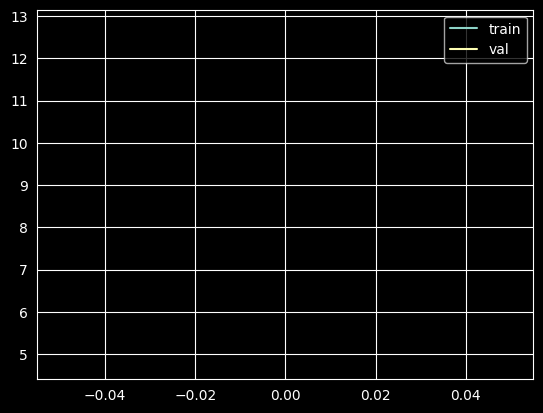

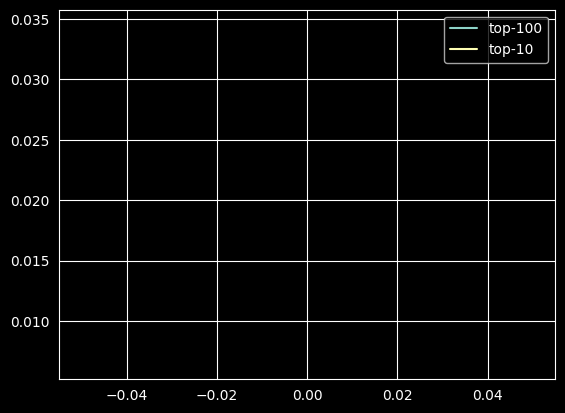

Training:   0%|          | 0/7921 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1: train_loss=4.2541, val_loss=13.9301, top10=0.0094, top100=0.0582


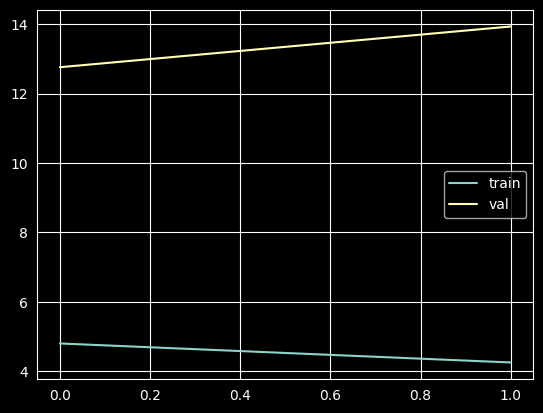

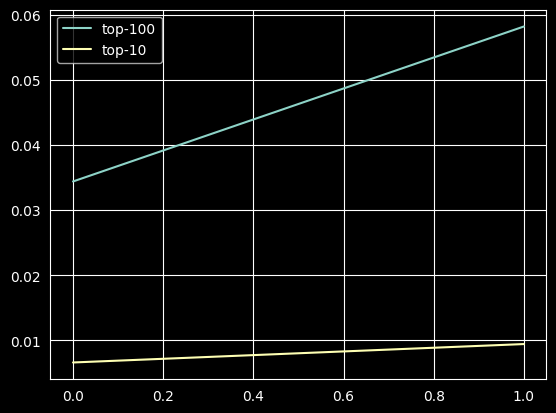

Training:   0%|          | 0/7921 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2: train_loss=3.9710, val_loss=13.5522, top10=0.0115, top100=0.0731


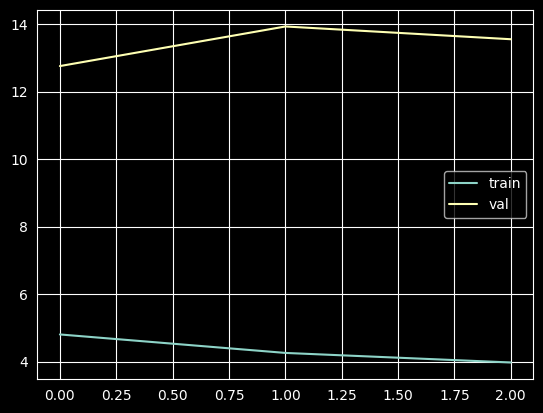

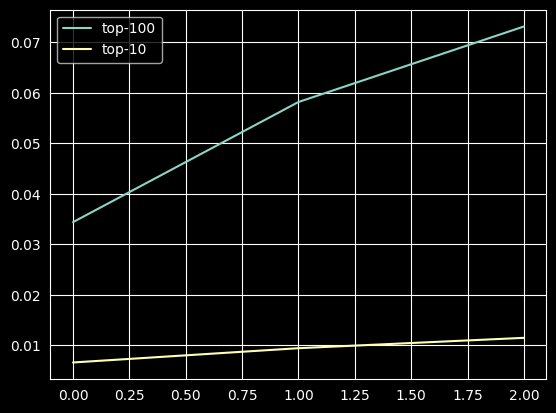

Training:   0%|          | 0/7921 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 3: train_loss=3.8123, val_loss=13.4829, top10=0.0187, top100=0.0902


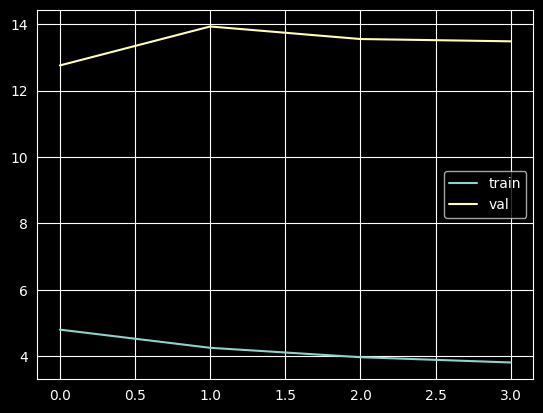

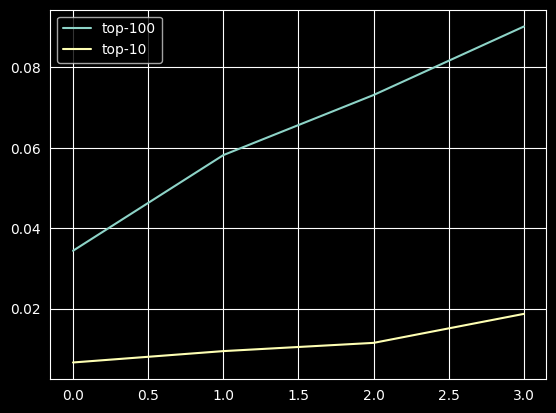

Training:   0%|          | 0/7921 [00:00<?, ?it/s]

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

train(model, train_loader, val_loader, optimizer, 5)

In [ ]:
val_loader = Utils.get_val_dataloader(val_dataset, batch_size=32, max_len=256,
                                      num_workers=0)


In [ ]:
validate_epoch(model, val_loader)

In [ ]:
torch.cuda.mem_get_info()

In [ ]:
torch.cuda.memory_reserved()

In [ ]:
torch.cuda.memory_allocated()

In [ ]:
print(torch.cuda.memory_summary())